In [4]:
import pandas as pd
df = pd.read_csv('/Cardiotocographic.csv')
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0



Perform an initial inspection of the dataset using methods like info(), describe(), and head() to understand its structure, data types, and basic statistics, and check for missing values.


In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None
                LB           AC           FM           UC           DL  \
count  2105.000000  2106.000000  2126.000000  2126.000000  2126.000000   
mean    133.343598     0.003219     0.009894     0.004391     0.001895   

## Handle Missing Values


In [ ]:
for column in ['LB', 'AC', 'DS', 'DP', 'MLTV', 'Width', 'Tendency', 'NSP']:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mean())
print(df.isnull().sum())

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64


## Identify and Correct Data Types

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None



Based on the previous output of df.info(), all columns are currently float64. As per the instructions, the 'NSP' column, representing 'Fetal State Class', should be converted to an integer type to reflect its categorical nature more accurately. After converting it, I'll display df.info() again to confirm the change.



In [ ]:
df['NSP'] = df['NSP'].astype(int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 232.7 KB
None


## Outlier Detection


Detect potential outliers in numerical features using statistical methods and visualize them using box plots to understand their impact.


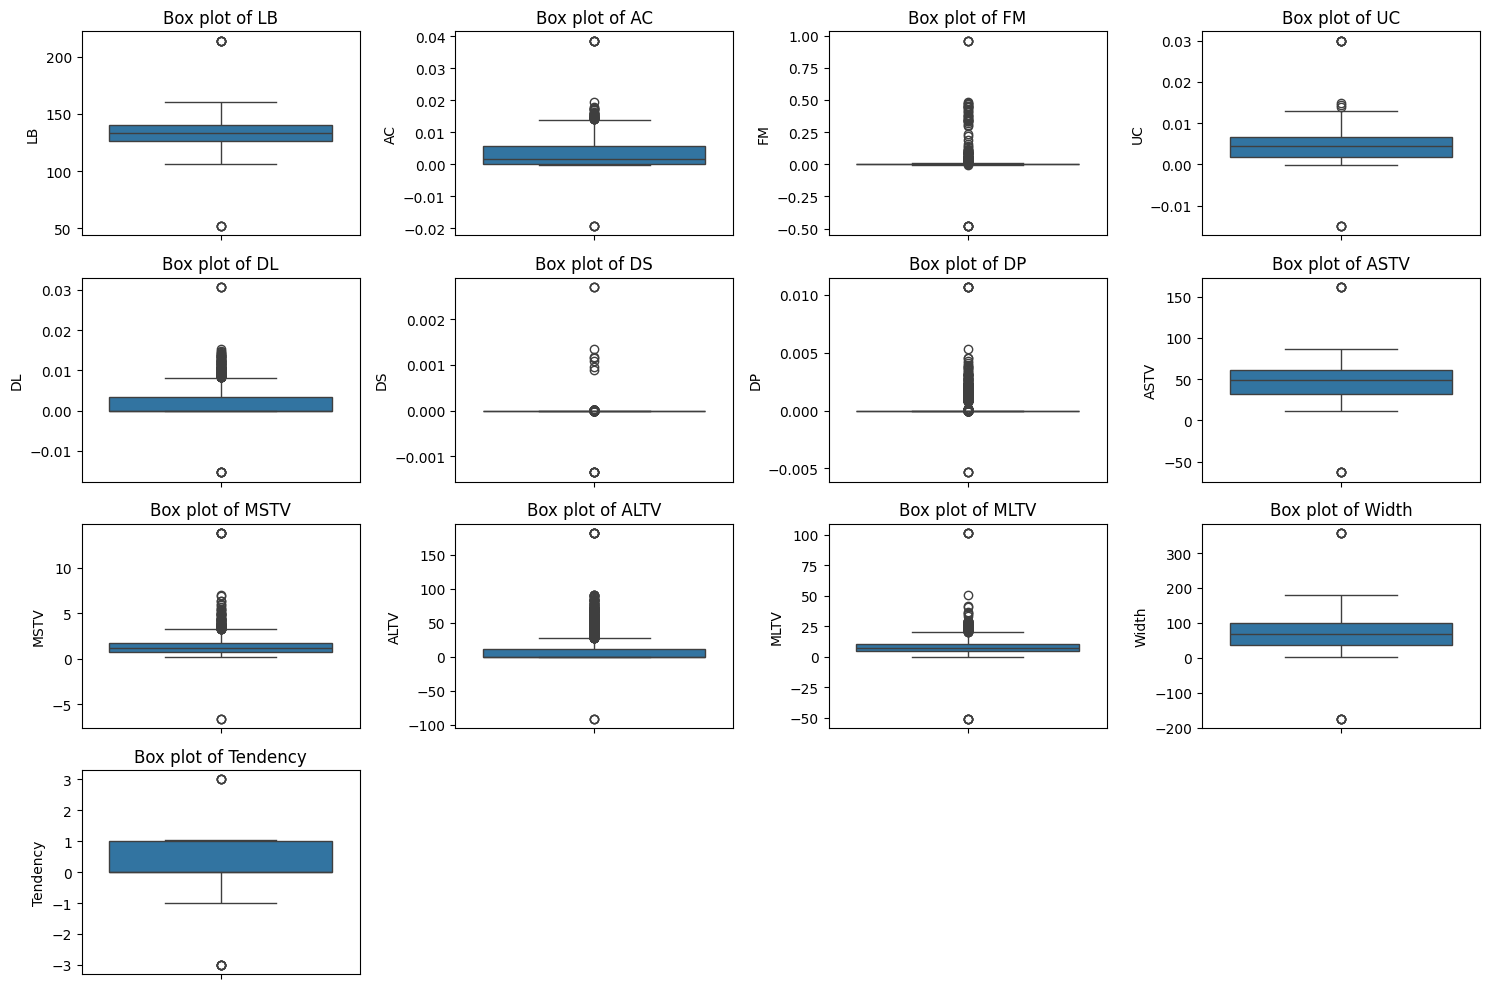

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'NSP' as it's a categorical feature, although currently int type
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.drop('NSP')

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column}')
    plt.tight_layout()
plt.show()

## Distribution Analysis

Visualize the distribution of key numerical features using histograms or kernel density plots to understand their shape, spread, and central tendency.


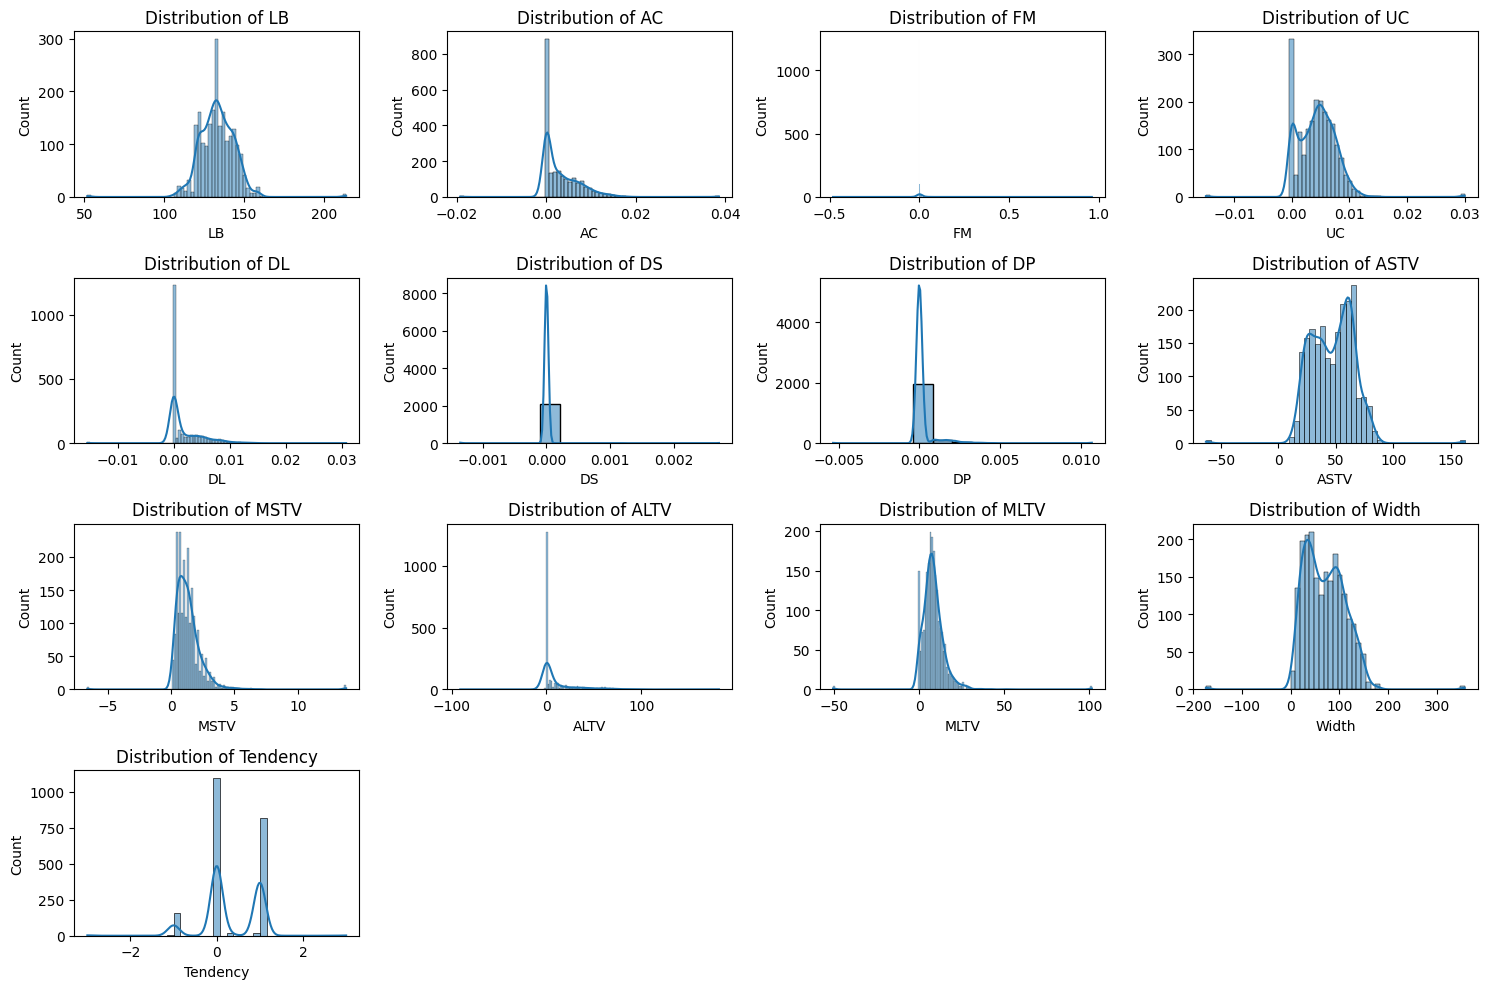

In [ ]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

## Correlation Matrix Visualization

Compute and visualize the correlation matrix of numerical features using a heatmap to identify relationships and dependencies between variables.


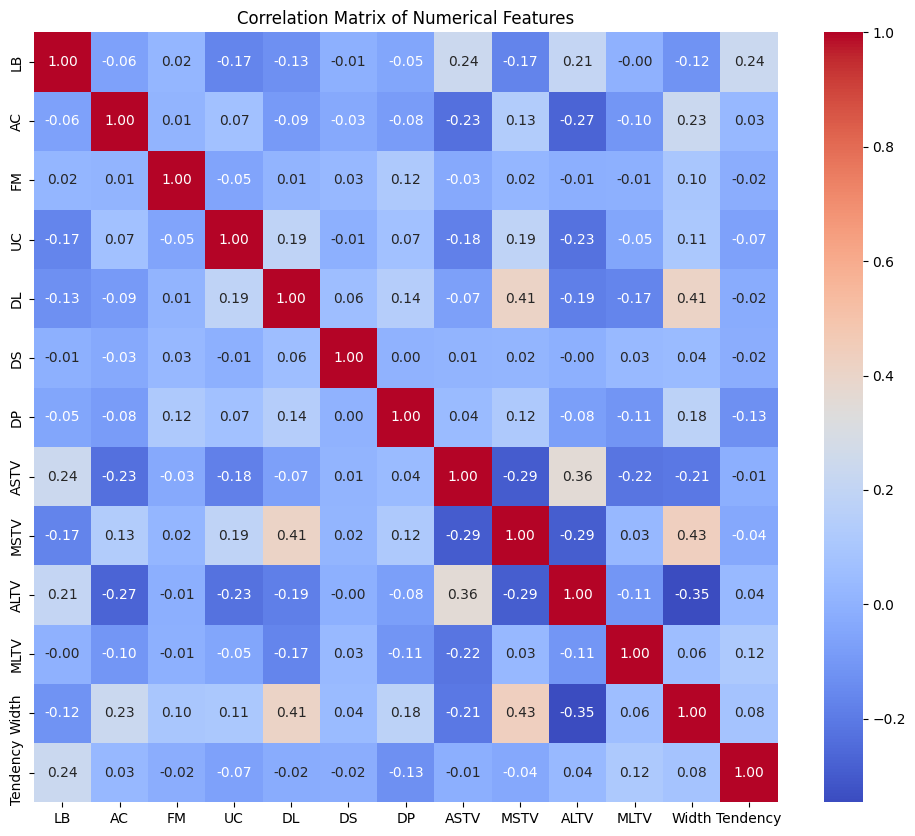

In [ ]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Summary:


*   The dataset initially contained 2126 entries and 14 columns. All columns were initially identified as float64 data types.
*   **Missing Values:** Eight columns (LB, AC, DS, DP, MLTV, Width, Tendency, NSP) had missing values. Specifically, LB, DS, DP, MLTV, Width, Tendency, and NSP each had 21 missing values, while AC had 20.
*   **Missing Value Imputation:** All identified missing values were successfully imputed by replacing them with the mean of their respective columns, ensuring a complete dataset for further analysis.
*   **Data Type Correction:** The 'NSP' column, representing 'Fetal State Class', was converted from float64 to int64 to better reflect its categorical nature.
*   **Potential Outliers:** Box plots revealed the presence of potential outliers in most numerical features, indicating values significantly deviating from the majority of the data points.
*   **Feature Distributions:** Histograms with Kernel Density Estimates (KDEs) were generated for all numerical features, providing visual insights into their shape, spread, and central tendency.
*   **Correlations:** A correlation matrix visualized through a heatmap identified relationships and dependencies between numerical variables, which can be crucial for feature selection or understanding underlying data structures.

